# Deep Learning Basics with PyTorch
# Part I - Foundations of Machine Learning
## Chapter 4: Limits and Scaling in Classical ML

This chapter uses tiny synthetic examples to show why some classical machine learning methods become harder to use as problems grow in dimension, feature count, data size, or model flexibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

np.set_printoptions(precision=3, suppress=True)
plt.style.use('seaborn-v0_8')
%config InlineBackend.figure_format = 'retina'


## Distance Concentration

In higher dimensions, distances between points tend to look more similar. This is one way to see the curse of dimensionality.


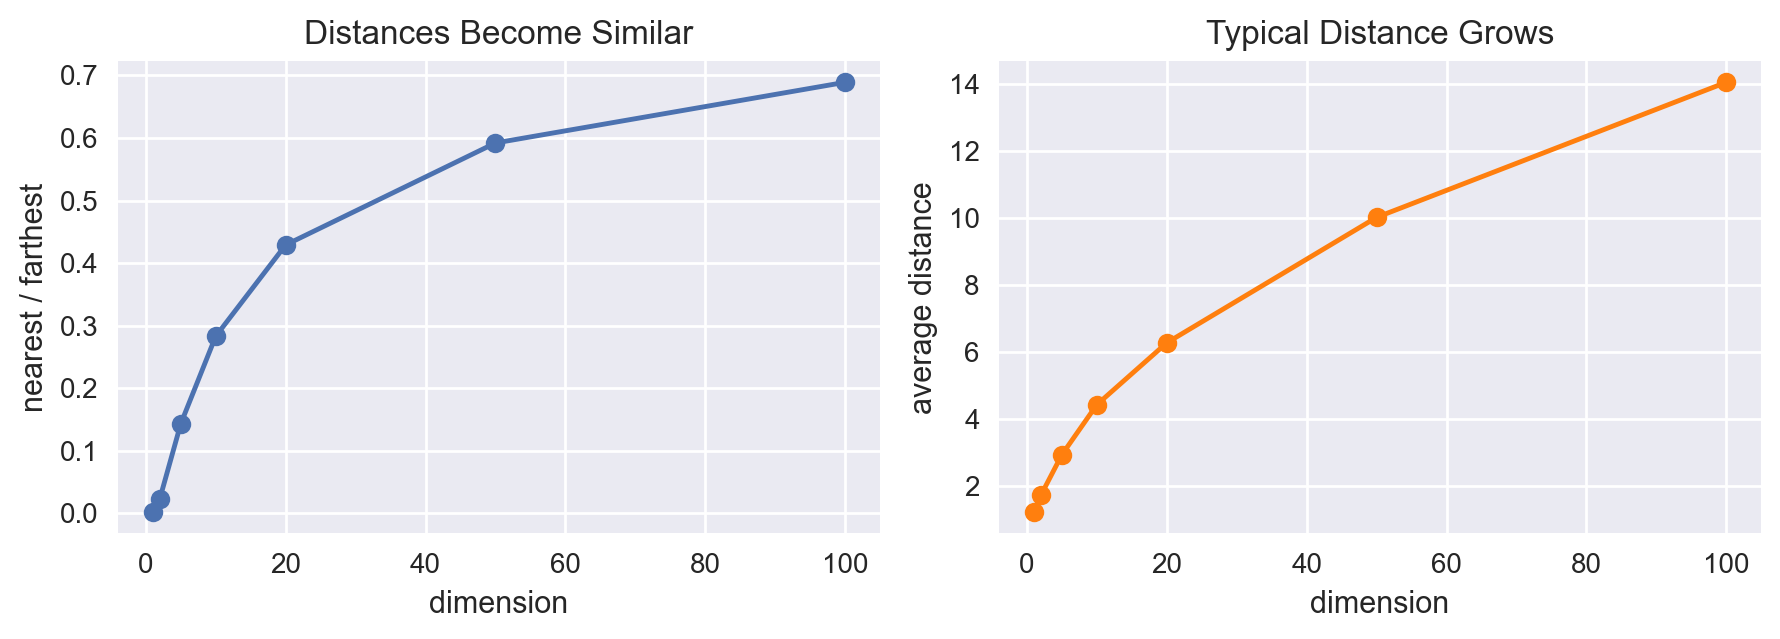

,dimension,nearest_over_farthest,mean_distance
0,1,0.002,1.222
1,2,0.023,1.723
2,5,0.143,2.930
3,10,0.283,4.422
4,20,0.429,6.267
5,50,0.592,10.009
6,100,0.689,14.037


In [2]:
rng = np.random.default_rng(0)
dims = [1, 2, 5, 10, 20, 50, 100]
rows = []

for d in dims:
    ratios = []
    mean_distances = []
    for _ in range(30):
        X = rng.normal(size=(400, d))
        anchor = X[0]
        distances = np.linalg.norm(X[1:] - anchor, axis=1)
        ratios.append(distances.min() / distances.max())
        mean_distances.append(distances.mean())
    rows.append({
        "dimension": d,
        "nearest_over_farthest": np.mean(ratios),
        "mean_distance": np.mean(mean_distances),
    })

distance_df = pd.DataFrame(rows).round(3)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].plot(distance_df["dimension"], distance_df["nearest_over_farthest"], marker="o")
ax[0].set_xlabel("dimension")
ax[0].set_ylabel("nearest / farthest")
ax[0].set_title("Distances Become Similar")

ax[1].plot(distance_df["dimension"], distance_df["mean_distance"], marker="o", color="tab:orange")
ax[1].set_xlabel("dimension")
ax[1].set_ylabel("average distance")
ax[1].set_title("Typical Distance Grows")

plt.tight_layout()
plt.show()

distance_df


## Polynomial Feature Growth

Adding polynomial features can make a model more flexible, but the number of terms can grow very quickly.


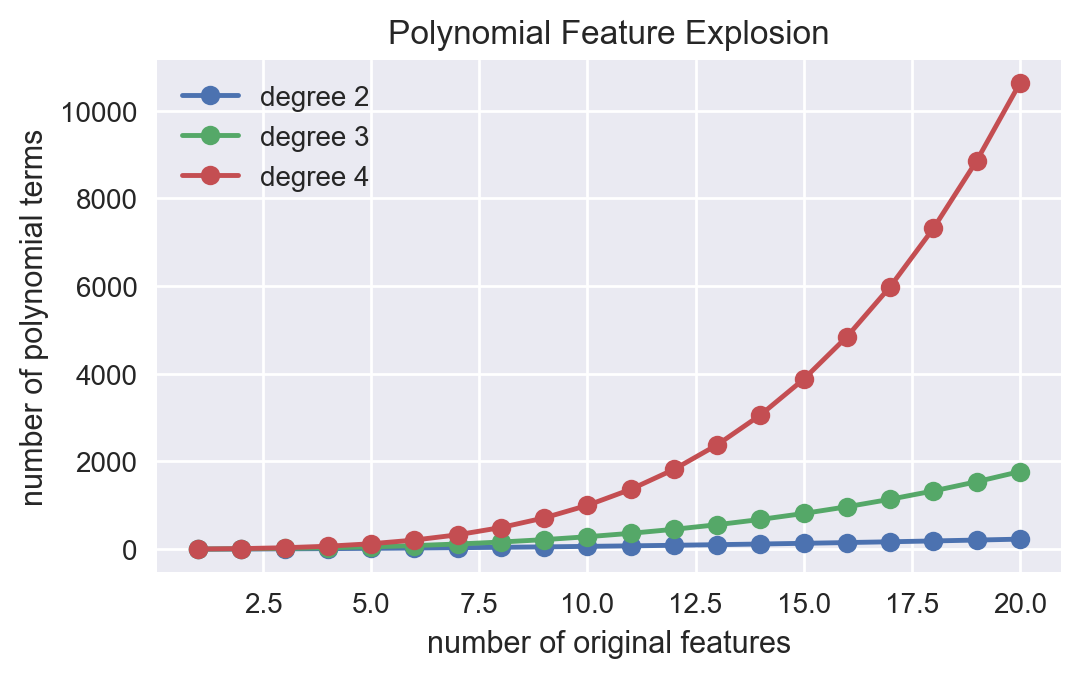

,n_features,degree_2_terms,degree_3_terms,degree_4_terms
0,1,2,3,4
1,2,5,9,14
2,5,20,55,125
3,10,65,285,1000
4,20,230,1770,10625


In [3]:
feature_counts = [1, 2, 5, 10, 20]
degrees = [2, 3, 4]
rows = []

for p in feature_counts:
    row = {"n_features": p}
    for degree in degrees:
        row[f"degree_{degree}_terms"] = comb(p + degree, degree) - 1
    rows.append(row)

poly_df = pd.DataFrame(rows)

p_values = np.arange(1, 21)
plt.figure(figsize=(5.5, 3.5))
for degree in degrees:
    term_counts = [comb(p + degree, degree) - 1 for p in p_values]
    plt.plot(p_values, term_counts, marker="o", label=f"degree {degree}")
plt.xlabel("number of original features")
plt.ylabel("number of polynomial terms")
plt.title("Polynomial Feature Explosion")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

poly_df


## Pairwise or Kernel Scaling Intuition

Methods that compare every example with every other example often need work or memory that grows like n^2.


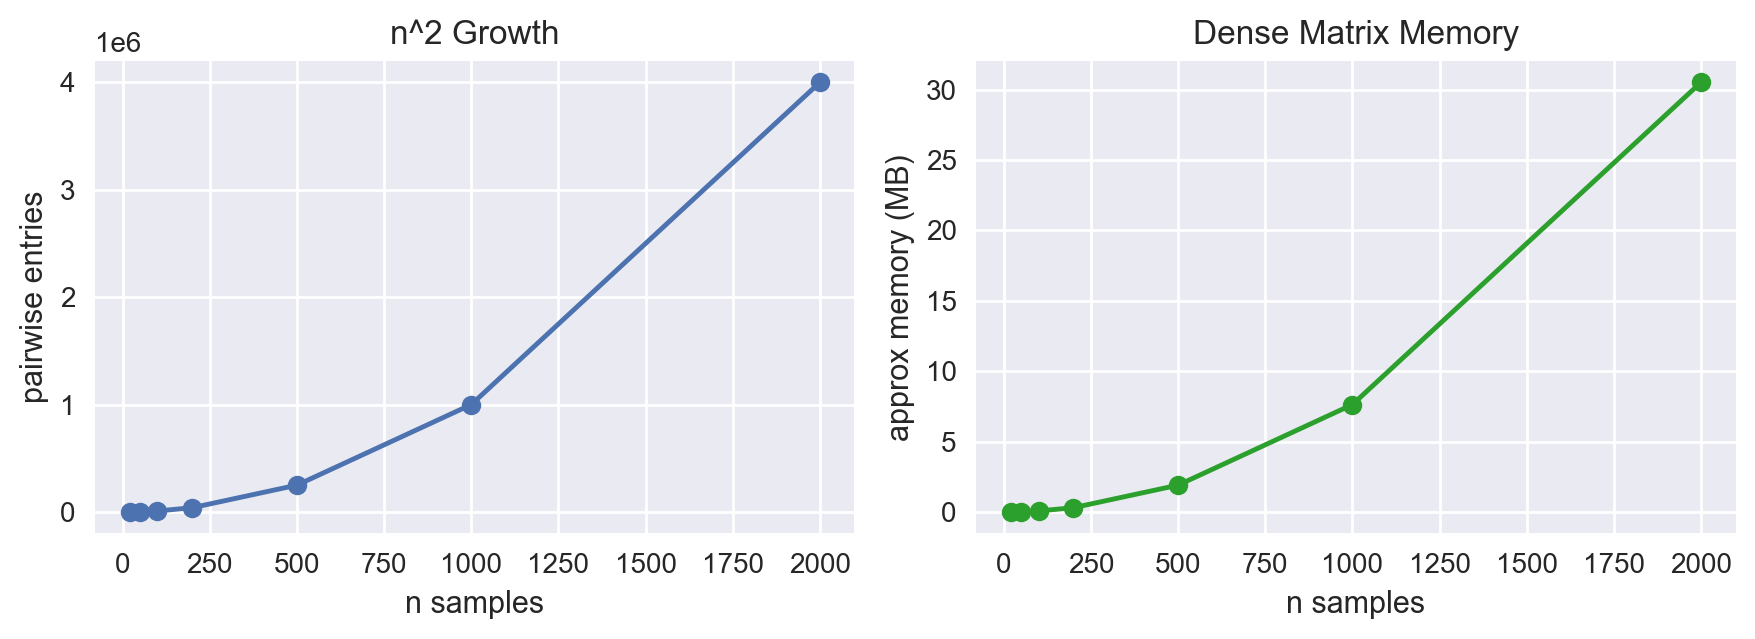

,n_samples,pairwise_entries,approx_memory_MB
0,20,400,0.003
1,50,2500,0.019
2,100,10000,0.076
3,200,40000,0.305
4,500,250000,1.907
5,1000,1000000,7.629
6,2000,4000000,30.518


In [4]:
sample_sizes = np.array([20, 50, 100, 200, 500, 1000, 2000])
pair_counts = sample_sizes ** 2
memory_mb = pair_counts * 8 / (1024 ** 2)

kernel_df = pd.DataFrame({
    "n_samples": sample_sizes,
    "pairwise_entries": pair_counts,
    "approx_memory_MB": np.round(memory_mb, 3),
})

fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].plot(sample_sizes, pair_counts, marker="o")
ax[0].set_xlabel("n samples")
ax[0].set_ylabel("pairwise entries")
ax[0].set_title("n^2 Growth")

ax[1].plot(sample_sizes, memory_mb, marker="o", color="tab:green")
ax[1].set_xlabel("n samples")
ax[1].set_ylabel("approx memory (MB)")
ax[1].set_title("Dense Matrix Memory")

plt.tight_layout()
plt.show()

kernel_df


## Model Complexity and Overfitting Intuition

More complex models can fit small details in the training data. That can help, but it can also make test performance worse.


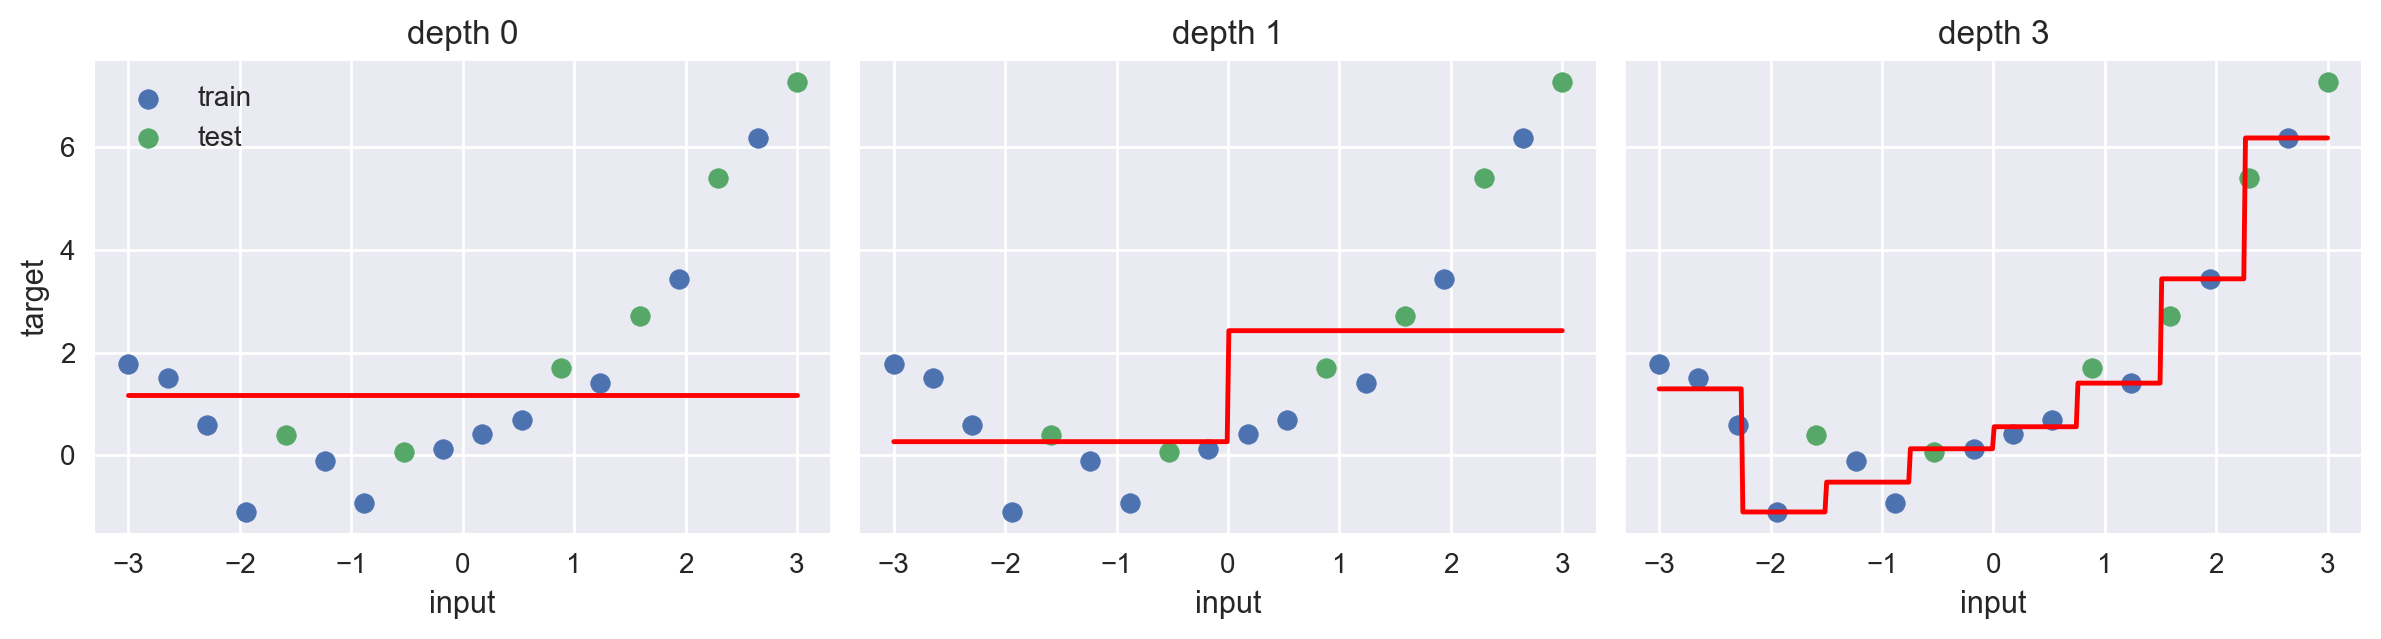

,depth,train_MSE,test_MSE
0,0,3.682,9.931
1,1,2.547,5.482
2,3,0.093,0.772


In [5]:
rng = np.random.default_rng(1)
x = np.linspace(-3, 3, 18)
y = 0.5 * x**2 + x + rng.normal(0, 0.8, size=len(x))

train_idx = np.array([0, 1, 2, 3, 5, 6, 8, 9, 10, 12, 14, 16])
test_idx = np.array([4, 7, 11, 13, 15, 17])
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

def piecewise_mean_predict(x_train, y_train, x_query, depth, x_min, x_max):
    n_bins = 2 ** depth
    edges = np.linspace(x_min, x_max, n_bins + 1)
    default_value = y_train.mean()
    bin_values = []
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (x_train >= edges[i]) & (x_train <= edges[i + 1])
        else:
            mask = (x_train >= edges[i]) & (x_train < edges[i + 1])
        if mask.any():
            bin_values.append(y_train[mask].mean())
        else:
            bin_values.append(default_value)
    preds = np.empty(len(x_query), dtype=float)
    for j, value in enumerate(x_query):
        idx = np.searchsorted(edges, value, side="right") - 1
        idx = int(np.clip(idx, 0, n_bins - 1))
        preds[j] = bin_values[idx]
    return preds

depths = [0, 1, 3]
rows = []
xx = np.linspace(x.min(), x.max(), 400)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3), sharey=True)

for i, depth in enumerate(depths):
    train_pred = piecewise_mean_predict(x_train, y_train, x_train, depth, x.min(), x.max())
    test_pred = piecewise_mean_predict(x_train, y_train, x_test, depth, x.min(), x.max())
    grid_pred = piecewise_mean_predict(x_train, y_train, xx, depth, x.min(), x.max())
    rows.append({
        "depth": depth,
        "train_MSE": np.mean((y_train - train_pred) ** 2),
        "test_MSE": np.mean((y_test - test_pred) ** 2),
    })
    ax[i].scatter(x_train, y_train, label="train")
    ax[i].scatter(x_test, y_test, label="test")
    ax[i].plot(xx, grid_pred, color="red")
    ax[i].set_title(f"depth {depth}")
    ax[i].set_xlabel("input")

ax[0].set_ylabel("target")
ax[0].legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame(rows).round(3)


## Learning Curve Example

A learning curve tracks what happens to training and test error as we give a model more data.


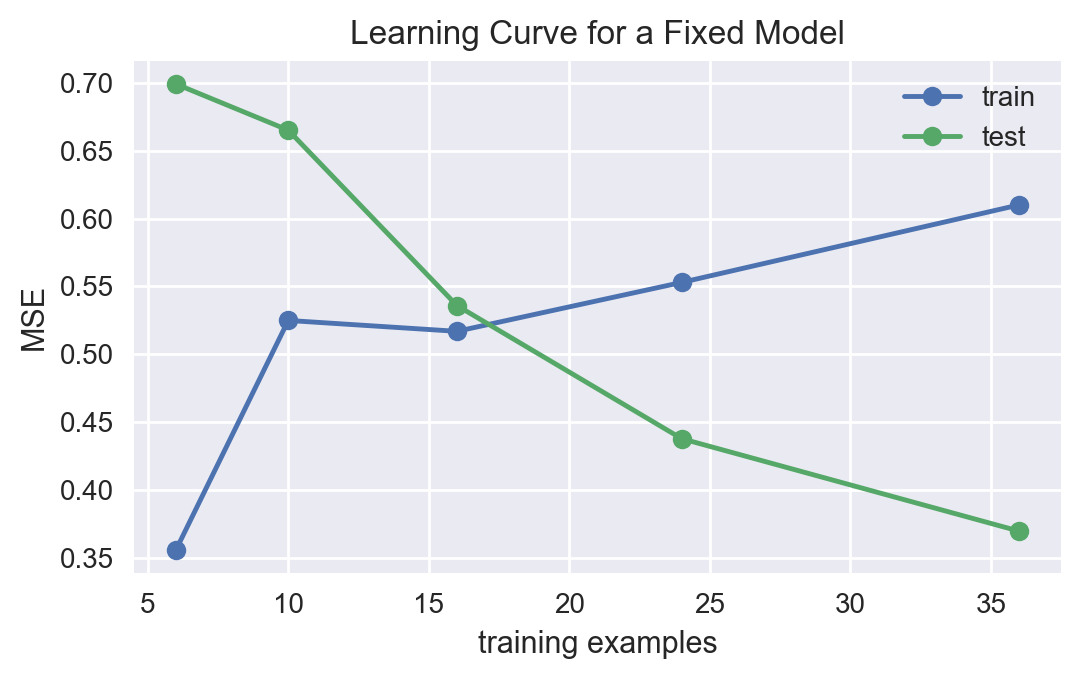

,train_size,mean_train_MSE,mean_test_MSE
0,6,0.356,0.699
1,10,0.525,0.665
2,16,0.517,0.536
3,24,0.553,0.438
4,36,0.610,0.370


In [6]:
rng = np.random.default_rng(3)
x_all = np.linspace(-3, 3, 60)
y_all = 0.5 * x_all**2 + x_all + rng.normal(0, 0.7, size=len(x_all))

test_mask = np.arange(len(x_all)) % 5 == 0
x_pool, y_pool = x_all[~test_mask], y_all[~test_mask]
x_test, y_test = x_all[test_mask], y_all[test_mask]

train_sizes = [6, 10, 16, 24, 36]
rows = []

for size in train_sizes:
    train_errors = []
    test_errors = []
    for _ in range(20):
        idx = rng.choice(len(x_pool), size=size, replace=False)
        x_train = x_pool[idx]
        y_train = y_pool[idx]
        coeffs = np.polyfit(x_train, y_train, deg=2)
        train_pred = np.polyval(coeffs, x_train)
        test_pred = np.polyval(coeffs, x_test)
        train_errors.append(np.mean((y_train - train_pred) ** 2))
        test_errors.append(np.mean((y_test - test_pred) ** 2))
    rows.append({
        "train_size": size,
        "mean_train_MSE": np.mean(train_errors),
        "mean_test_MSE": np.mean(test_errors),
    })

learning_df = pd.DataFrame(rows).round(3)

plt.figure(figsize=(5.5, 3.5))
plt.plot(learning_df["train_size"], learning_df["mean_train_MSE"], marker="o", label="train")
plt.plot(learning_df["train_size"], learning_df["mean_test_MSE"], marker="o", label="test")
plt.xlabel("training examples")
plt.ylabel("MSE")
plt.title("Learning Curve for a Fixed Model")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

learning_df


## Residuals Under Misspecification

Residuals can reveal when a model is missing an important pattern. Here we fit a line to data that is actually curved.


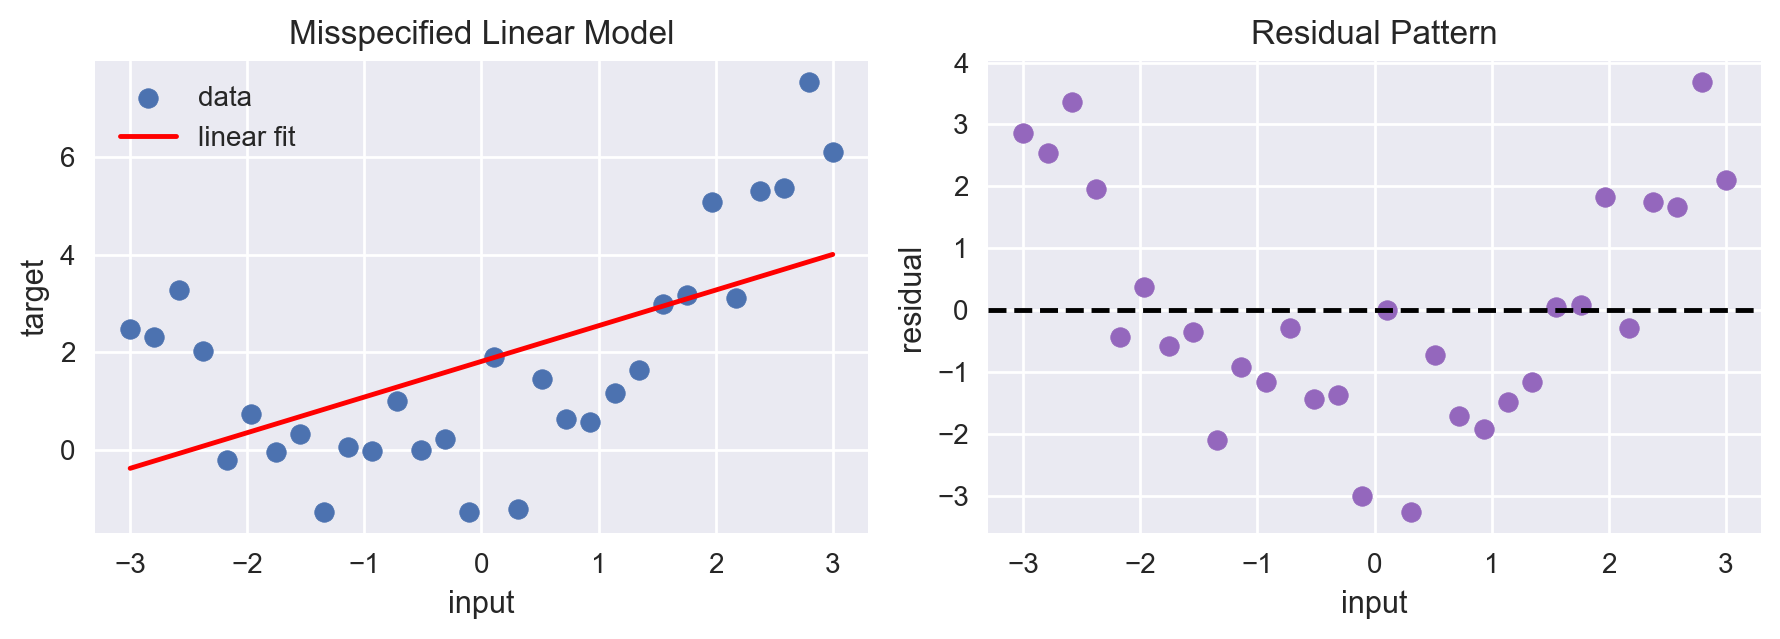

residual mean: 0.000
residual std: 1.815


In [7]:
rng = np.random.default_rng(4)
x = np.linspace(-3, 3, 30)
y = 0.6 * x**2 + 0.8 * x + rng.normal(0, 0.8, size=len(x))

slope, intercept = np.polyfit(x, y, deg=1)
y_pred = slope * x + intercept
residuals = y - y_pred

fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].scatter(x, y, label="data")
ax[0].plot(x, y_pred, color="red", label="linear fit")
ax[0].set_xlabel("input")
ax[0].set_ylabel("target")
ax[0].set_title("Misspecified Linear Model")
ax[0].legend(frameon=False)

ax[1].scatter(x, residuals, color="tab:purple")
ax[1].axhline(0, color="black", linestyle="--")
ax[1].set_xlabel("input")
ax[1].set_ylabel("residual")
ax[1].set_title("Residual Pattern")

plt.tight_layout()
plt.show()

print(f"residual mean: {residuals.mean():.3f}")
print(f"residual std: {residuals.std():.3f}")


## Chapter 4 Summary

- In higher dimensions, distances become less informative because points start to look similarly far apart.
- Polynomial expansions can grow feature counts very quickly.
- Pairwise methods can become expensive because their memory and computation often scale like n^2.
- More flexible models can overfit small datasets even when they reduce training error.
- Learning curves and residual plots are useful tools for spotting limitations in a model.
